# NCAA Forwards Clustering Via Advanced Metrics

In [52]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Roadmap

+ [x] Load in CSV for forward advanced position metrics
+ [] Perform surface-level EDA
+ [] Standardize column formatting, syntax, and normalize values 
+ [] Continually think about feature engineering regarding minutes played and continuous numerical features
    + Make sure to not incur data leakage
+ [] Run elbow method on optimal amount of clusters
+ [] Perform clustering on the forward dataset as a rat experiment
+ [] Apply PCA for dimensionality deduction







In [53]:
df = pd.read_csv('forward_metrics.csv')

df.head()

,Player,Position,Team,ES IND XGFP20,ES ACT2XPF,SOO,SOOdiff,SOT%,ES OZ F/O Wins,ES OZ F/O Win %,ES DZ F/O Wins,ES DZ F/O Win %,ES ISF (P20 WOI),ES ISA (P20 WOI),ES ISF% (WOI),ES OZSTART %,ES XGFP20 (WOI),ES XGAP20 (WOI),XGF %,ES CORSIFOR%
0,Aidan Willis,F,Air Force Academy Falcons,0.217212,-0.053873,22.907956,0.791295,0.237162,18,0.382979,20,0.370370,2.123412,1.905626,0.527027,0.329923,0.972144,0.922395,0.513130,0.522599
1,Anthony Yu,F,Air Force Academy Falcons,0.131096,-0.075379,23.748756,-0.758186,0.140521,0,0.000000,1,1.000000,1.782962,2.563007,0.410256,0.331593,0.995454,1.209292,0.451505,0.483161
2,Brendan Gibbons,F,Air Force Academy Falcons,0.255148,-0.038597,23.285188,1.573266,0.274256,1,0.333333,1,0.333333,2.078892,1.948961,0.516129,0.364407,1.055192,1.062285,0.498325,0.526030
3,Cade Moxham,F,Air Force Academy Falcons,0.206817,-0.206817,21.213300,2.313442,0.278787,0,0.000000,0,0.000000,0.538535,2.154141,0.200000,0.352941,0.786097,1.199363,0.395927,0.589041
4,Charles Panchisin,F,Air Force Academy Falcons,0.194553,-0.063844,23.032880,-0.863659,0.196367,3,1.000000,0,0.000000,2.091332,2.222041,0.484848,0.425606,0.878276,1.188001,0.425052,0.498299


In [54]:
print(df.columns)

Index(['Player', 'Position', 'Team', 'ES IND XGFP20', 'ES ACT2XPF', 'SOO',
       'SOOdiff', 'SOT%', 'ES OZ F/O Wins', 'ES OZ F/O Win %',
       'ES DZ F/O Wins', 'ES DZ F/O Win %', 'ES ISF (P20 WOI)',
       'ES ISA (P20 WOI)', 'ES ISF% (WOI)', 'ES OZSTART %', 'ES XGFP20 (WOI)',
       'ES XGAP20 (WOI)', 'XGF %', 'ES CORSIFOR%'],
      dtype='object')


In [55]:
print(df.isna().sum())

Player              0
Position            0
Team                0
ES IND XGFP20       0
ES ACT2XPF          0
SOO                 0
SOOdiff             0
SOT%                0
ES OZ F/O Wins      0
ES OZ F/O Win %     0
ES DZ F/O Wins      0
ES DZ F/O Win %     0
ES ISF (P20 WOI)    0
ES ISA (P20 WOI)    0
ES ISF% (WOI)       0
ES OZSTART %        0
ES XGFP20 (WOI)     0
ES XGAP20 (WOI)     0
XGF %               0
ES CORSIFOR%        0
dtype: int64


+ Good data normalicy, cleanliness
+ Have to improve on column names, formatting, spacing, and pruning some unnecessary features

In [56]:
df.columns = df.columns.str.replace(' ','_').str.lower()
df.columns = df.columns.str.replace('%', 'percent').str.replace('/', '_')
df.columns


Index(['player', 'position', 'team', 'es_ind_xgfp20', 'es_act2xpf', 'soo',
       'soodiff', 'sotpercent', 'es_oz_f_o_wins', 'es_oz_f_o_win_percent',
       'es_dz_f_o_wins', 'es_dz_f_o_win_percent', 'es_isf_(p20_woi)',
       'es_isa_(p20_woi)', 'es_isfpercent_(woi)', 'es_ozstart_percent',
       'es_xgfp20_(woi)', 'es_xgap20_(woi)', 'xgf_percent',
       'es_corsiforpercent'],
      dtype='object')

In [57]:
df.dtypes

player                    object
position                  object
team                      object
es_ind_xgfp20            float64
es_act2xpf               float64
soo                      float64
soodiff                  float64
sotpercent               float64
es_oz_f_o_wins             int64
es_oz_f_o_win_percent    float64
es_dz_f_o_wins             int64
es_dz_f_o_win_percent    float64
es_isf_(p20_woi)         float64
es_isa_(p20_woi)         float64
es_isfpercent_(woi)      float64
es_ozstart_percent       float64
es_xgfp20_(woi)          float64
es_xgap20_(woi)          float64
xgf_percent              float64
es_corsiforpercent       float64
dtype: object

In [58]:
print(df['position'].value_counts())
print(df['team'].value_counts())

# get rid of forward column, obsolete


position
F    987
Name: count, dtype: int64
team
Canisius College Golden Griffins            19
Michigan Tech University Huskies            18
University of Alaska Fairbanks Nanooks      18
Bentley University Falcons                  18
University of Alaska Anchorage Seawolves    18
                                            ..
University of Minnesota Golden Gophers      14
Providence College Friars                   14
Minnesota State University Mavericks        14
Clarkson University Golden Knights          14
Michigan Wolverines                         13
Name: count, Length: 63, dtype: int64


In [59]:
df = df.drop(columns=['position'])
df.head()


,player,team,es_ind_xgfp20,es_act2xpf,soo,soodiff,sotpercent,es_oz_f_o_wins,es_oz_f_o_win_percent,es_dz_f_o_wins,es_dz_f_o_win_percent,es_isf_(p20_woi),es_isa_(p20_woi),es_isfpercent_(woi),es_ozstart_percent,es_xgfp20_(woi),es_xgap20_(woi),xgf_percent,es_corsiforpercent
0,Aidan Willis,Air Force Academy Falcons,0.217212,-0.053873,22.907956,0.791295,0.237162,18,0.382979,20,0.370370,2.123412,1.905626,0.527027,0.329923,0.972144,0.922395,0.513130,0.522599
1,Anthony Yu,Air Force Academy Falcons,0.131096,-0.075379,23.748756,-0.758186,0.140521,0,0.000000,1,1.000000,1.782962,2.563007,0.410256,0.331593,0.995454,1.209292,0.451505,0.483161
2,Brendan Gibbons,Air Force Academy Falcons,0.255148,-0.038597,23.285188,1.573266,0.274256,1,0.333333,1,0.333333,2.078892,1.948961,0.516129,0.364407,1.055192,1.062285,0.498325,0.526030
3,Cade Moxham,Air Force Academy Falcons,0.206817,-0.206817,21.213300,2.313442,0.278787,0,0.000000,0,0.000000,0.538535,2.154141,0.200000,0.352941,0.786097,1.199363,0.395927,0.589041
4,Charles Panchisin,Air Force Academy Falcons,0.194553,-0.063844,23.032880,-0.863659,0.196367,3,1.000000,0,0.000000,2.091332,2.222041,0.484848,0.425606,0.878276,1.188001,0.425052,0.498299


# Proportion columns vs Continuous columns

**Proportion**
+ sotpercent
+ es_oz_f/o_win_percent
+ es_dz_f/o_win_percent
+ es_ozstart_percent
+ es_isfpercent_(woi)
+ xgf_percent
+ es_corsiforpercent

**Continuous**
+ es_ind_xgfp20
    + This column is marginally dispursed, not a percent
+ es_act2xpf
+ soo
+ soodiff
    + Could be a source of data leakage being so highly correlated with soo
    

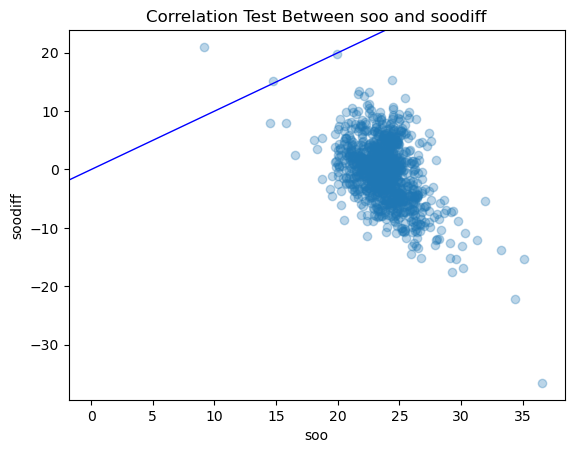

In [60]:
# Scatterplot of Soo vs Soodiff
# + Maybe plot soo vs sotpercent

# viz residuals

import matplotlib.pyplot as plt

plt.scatter(df['soo'], df['soodiff'], alpha=0.3)
plt.xlabel('soo')
plt.ylabel('soodiff')
plt.title('Correlation Test Between soo and soodiff')
plt.axline((0,0), (1, 1), color='blue', linewidth=1)

plt.show()

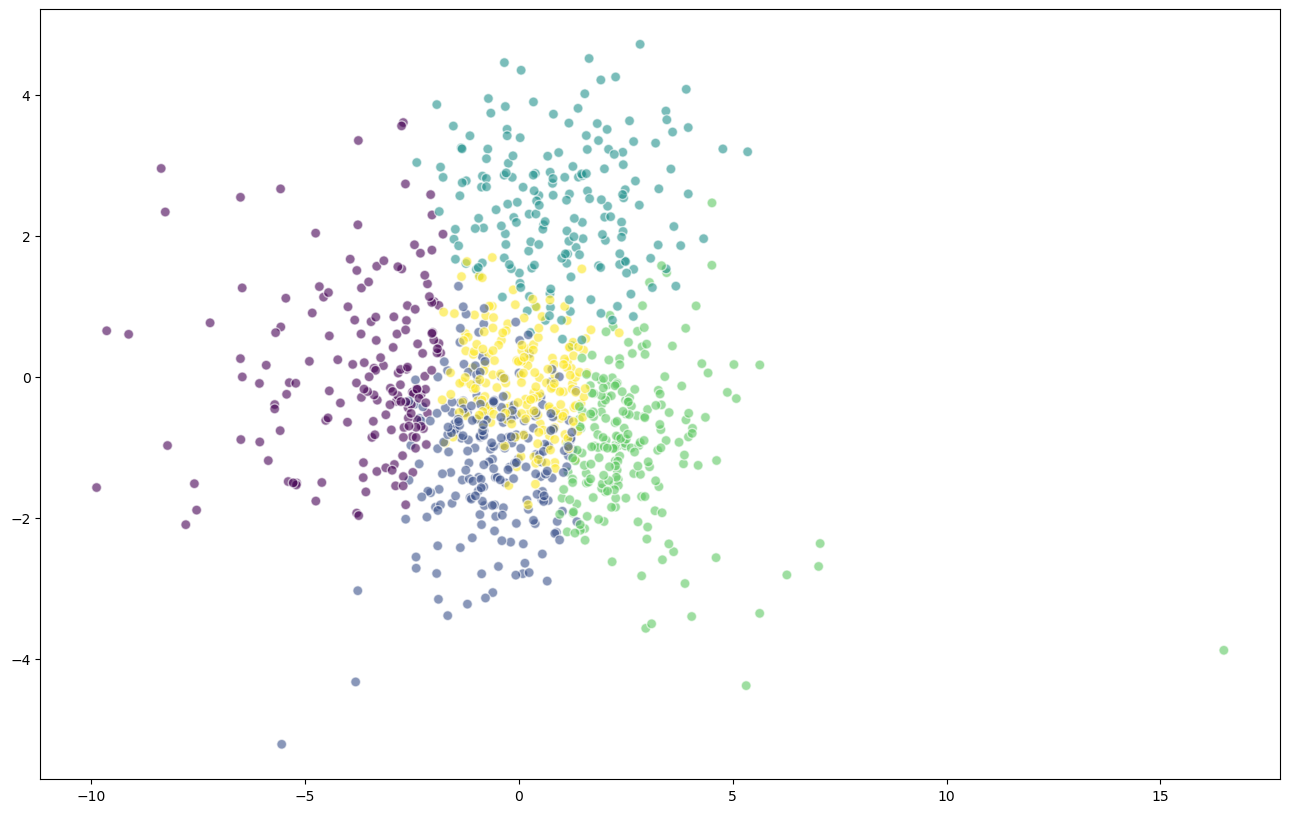

In [61]:
scaler = StandardScaler()

scaled_df = scaler.fit_transform(df.drop(columns=['player', 'team']))

kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_df)

pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)
df['PCA1'] = pca_components[:, 0]
df['PCA2'] = pca_components[:, 1]

# 7. Visualization
plt.figure(figsize=(16, 10))

# Plot all clusters
scatter = plt.scatter(
    df['PCA1'], 
    df['PCA2'], 
    c=df['Cluster'], 
    cmap='viridis', 
    alpha=0.6, 
    s=50,
    edgecolors='w'
)



In [62]:
feature_cols = [col for col in df.columns.drop(columns=['player', 'team'])]

# Get the components (weights)
components = pd.DataFrame(pca.components_, columns=feature_cols, index=['PCA1', 'PCA2'])

# Get top 3 positive and negative contributing features for PCA1
pca1_top_pos = components.loc['PCA1'].nlargest(3)
pca1_top_neg = components.loc['PCA1'].nsmallest(3)

print("\nPrincipal Component 1 (X-Axis) is primarily driven by:")
print("Positive drivers (Moving Right):")
for feat, val in pca1_top_pos.items(): print(f"  + {feat} ({val:.2f})")
print("Negative drivers (Moving Left):")
for feat, val in pca1_top_neg.items(): print(f"  - {feat} ({val:.2f})")

# Get top 3 positive and negative contributing features for PCA2
pca2_top_pos = components.loc['PCA2'].nlargest(3)
pca2_top_neg = components.loc['PCA2'].nsmallest(3)

print("\nPrincipal Component 2 (Y-Axis) is primarily driven by:")
print("Positive drivers (Moving Up):")
for feat, val in pca2_top_pos.items(): print(f"  + {feat} ({val:.2f})")
print("Negative drivers (Moving Down):")
for feat, val in pca2_top_neg.items(): print(f"  - {feat} ({val:.2f})")

TypeError: Index.drop() got an unexpected keyword argument 'columns'